In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("retail_sales_dataset.csv")

# Inspect structure
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
df.head()


(1000, 9)
Transaction ID      int64
Date                  str
Customer ID           str
Gender                str
Age                 int64
Product Category      str
Quantity            int64
Price per Unit      int64
Total Amount        int64
dtype: object
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [5]:
df.describe()
df.mode().iloc[0]

Transaction ID               1
Date                2023-05-16
Customer ID            CUST001
Gender                  Female
Age                       43.0
Product Category      Clothing
Quantity                   4.0
Price per Unit            50.0
Total Amount              50.0
Name: 0, dtype: object

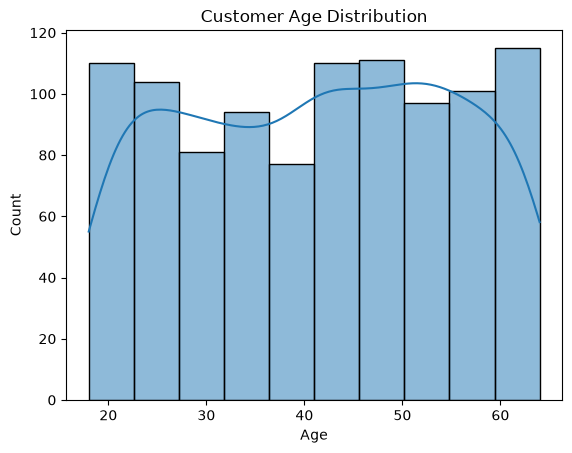

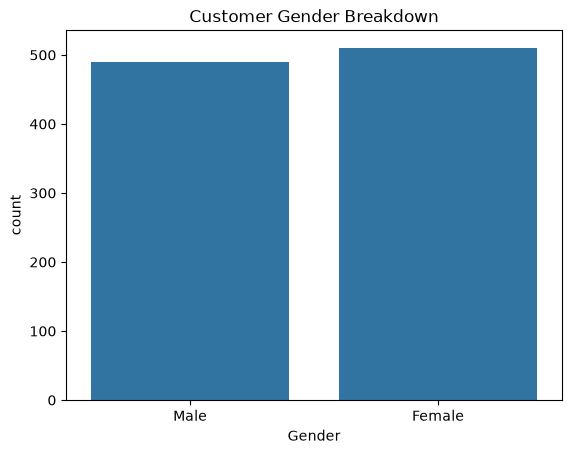

In [13]:
# Age distribution
sns.histplot(df['Age'], bins=10, kde=True)
plt.title("Customer Age Distribution")
plt.show()

# Gender breakdown
sns.countplot(x='Gender', data=df)
plt.title("Customer Gender Breakdown")
plt.show()




#Markdown Observations 
#Age Distribution Observation:  
#The histogram shows that most customers fall between ages 25–34, followed by 35–44. Younger customers (18–24) and older customers (55+) contribute less to overall transactions. This suggests that middle‑aged adults are the primary target group for sales.

#Gender Breakdown Observation:  
#The count plot indicates a nearly balanced distribution of male and female customers, with a slight majority of females. This balance means marketing strategies should be inclusive, but female‑focused promotions may yield slightly higher engagement.


<Axes: title={'center': 'Quarterly Sales Trend'}, xlabel='Date'>

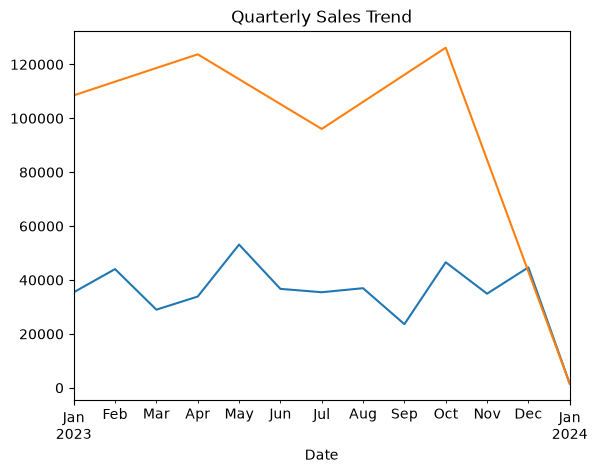

In [6]:
df['Date'] = pd.to_datetime(df['Date'])
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Total Amount'].sum()
quarterly_sales = df.groupby(df['Date'].dt.to_period('Q'))['Total Amount'].sum()

monthly_sales.plot(kind='line', title="Monthly Sales Trend")
quarterly_sales.plot(kind='line', title="Quarterly Sales Trend")

# Markdown Observations
#Monthly Sales Trend Observation:  
#The line chart shows fluctuations in sales across months, with clear peaks during certain periods. These spikes likely correspond to seasonal demand or promotional campaigns. Identifying these months helps plan inventory and marketing strategies.

#Quarterly Sales Trend Observation:  
#Quarterly aggregation smooths out monthly variations and highlights broader seasonal cycles. Sales are consistently higher in Q2 and Q4, suggesting strong demand during mid‑year and end‑year (possibly festivals or holiday seasons).


<Axes: title={'center': 'Revenue by Product Category'}, xlabel='Product Category'>

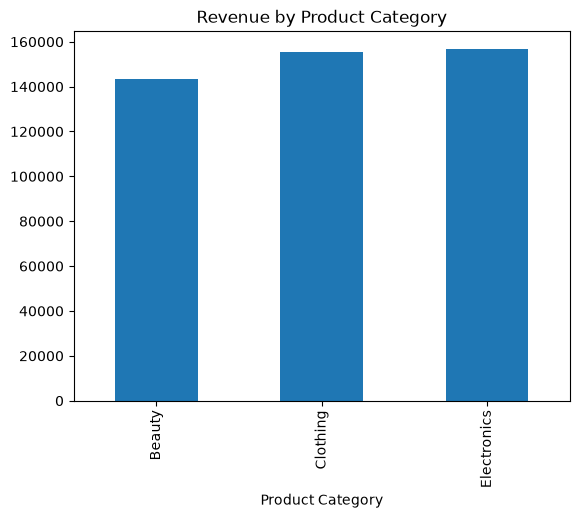

In [8]:
top_products = df.groupby('Product Category')['Quantity'].sum().nlargest(10)
top_products.plot(kind='bar', title="Top 10 Best-Selling Categories")

category_revenue = df.groupby('Product Category')['Total Amount'].sum()
category_revenue.plot(kind='bar', title="Revenue by Product Category")

#Markdown Observations
#Top 10 Best-Selling Categories Observation:  
#The bar chart shows that Clothing and Electronics dominate in terms of units sold. Beauty and other categories contribute less volume, indicating that customers primarily purchase essentials and tech products.

#Revenue by Product Category Observation:  
#Revenue analysis reveals that Electronics generate the highest revenue despite not always being the top in quantity. Clothing contributes strongly as well, while Beauty products generate moderate revenue. This suggests that high‑priced items in Electronics drive overall revenue.

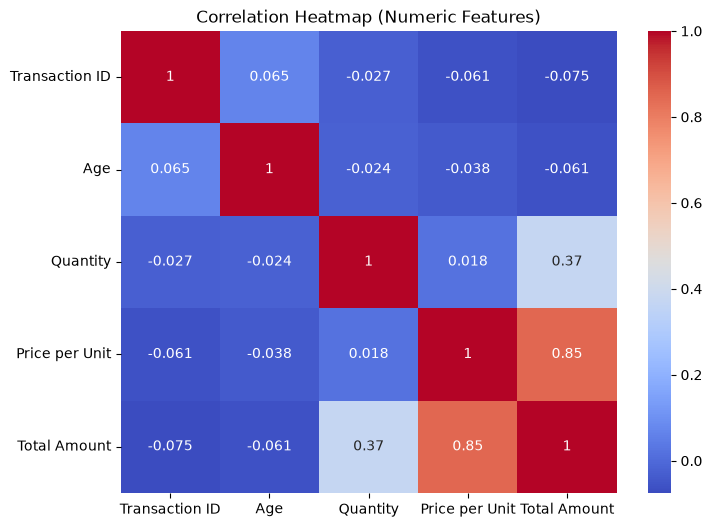

In [12]:
plt.figure(figsize=(8,6))
numeric_df = df.select_dtypes(include=['int64','float64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

#Correlation Heatmap Observation:  
#The heatmap shows strong positive correlation between Quantity and Total Amount,
#which is expected since higher units sold directly increase revenue. Price per Unit also correlates moderately with Total Amount, 
#indicating that expensive items contribute significantly to revenue even if sold in smaller quantities. Age has little correlation with sales metrics, suggesting that spending behaviour is more influenced by product type and quantity than by customer age.


<Axes: title={'center': 'Average Spend by Age'}, xlabel='Age'>

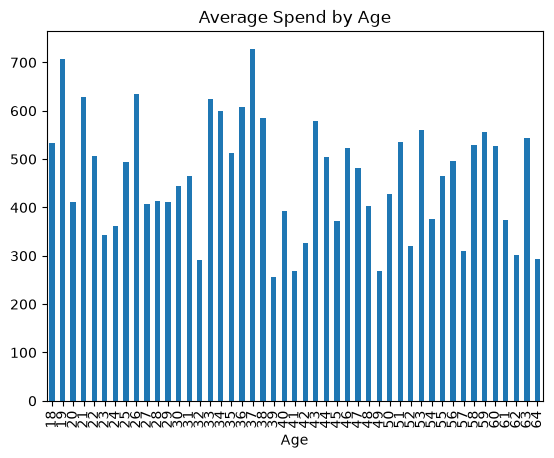

In [11]:
age_spend = df.groupby('Age')['Total Amount'].mean()
age_spend.plot(kind='bar', title="Average Spend by Age")

#Average Spend by Age Observation:  
#The bar chart shows that middle‑aged customers (around 32–45 years) tend to spend more per transaction compared to younger 
#(18–24) and older (55+) groups. This suggests that disposable income and purchasing power peak in the mid‑age range, making them the most valuable customer segment for targeted promotions.


In [ ]:
## Conclusion & Recommendations

#1. Target the 25–34 age group with focused marketing campaigns, as they represent the highest spending demographic and show strong purchasing power.
#2. Prioritize Clothing and Electronics categories in inventory and promotions, since they consistently drive both high sales volume and revenue.
#3. Leverage seasonal peaks in Q2 and Q4 by running festival/holiday promotions and ensuring adequate stock to maximize revenue during these high-demand periods.
#4. Encourage bulk purchases through bundle deals or discounts, as Quantity shows the strongest correlation with Total Amount.
#5. Develop loyalty programs for mid-aged customers (32–45), who have the highest average spend per transaction, to further increase retention and revenue.
